# Optativa III: Ciencia de Datos
## Semana 4 — Procesamiento y limpieza de datos (Data Wrangling con pandas)

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 4 · Sesión 1**

---

### Propósito

En ciencia de datos, entre el **70% y el 80% del tiempo** se dedica a limpiar y preparar datos. Un modelo brillante sobre datos sucios produce basura. En esta actividad aprenderás **data wrangling**: cargar datos desde **múltiples fuentes** (CSV, JSON, SQL) y resolver los problemas más comunes: **valores nulos, duplicados, tipos de datos incorrectos, formato inconsistente y valores atípicos**.

La actividad tiene dos partes:

- **PARTE A — Ejemplo guiado por el profesor.** Limpiaremos juntos, paso a paso, un dataset "sucio" de ventas. Observa cada técnica y responde las preguntas.
- **PARTE B — Tu turno.** Aplicarás lo aprendido de forma autónoma sobre datos de clientes (JSON) y productos (SQL), completando el código.

Responderás **50 preguntas** en total, modificando el código, analizando resultados e interpretando.

### Los datasets (súbelos a Colab antes de empezar)

- `ventas_sucias.csv` — ventas de una tienda, con muchos problemas de calidad.
- `clientes.json` — datos de clientes en formato JSON.
- `tienda.db` — base de datos SQLite con una tabla de productos.

Sube los tres archivos con el panel de archivos de Colab (icono de carpeta → subir).

### Cómo trabajar

Ejecuta cada celda con **Shift + Enter** en orden, responde las preguntas (doble clic), completa los retos y, al final, guarda una copia en Drive y entrégala en Classroom.


---
# PARTE A — Ejemplo guiado por el profesor

## Paso 0 — Cargar librerías


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sqlite3

pd.set_option("display.max_columns", None)
print("Librerias cargadas.")

Librerias cargadas.


> **1.** ¿Por qué se dice que la limpieza de datos consume la mayor parte del tiempo de un proyecto de ciencia de datos? ¿Qué pasaría si entrenáramos un modelo sin limpiar los datos?

**Respuesta:** Porque los datos del mundo real casi nunca llegan listos: vienen de sistemas distintos, capturados por personas, con errores de dedo, formatos mezclados, campos vacíos y registros repetidos. Detectar y corregir cada uno de esos problemas (como haremos aquí: nulos, duplicados, tipos, texto inconsistente, valores imposibles, outliers) toma mucho más tiempo que ejecutar el análisis en sí. Si entrenáramos un modelo sin limpiar, aprendería de basura: promedios inflados por duplicados y outliers, categorías fragmentadas ("mexico" y "México" como cosas distintas), edades de 200 años... El resultado serían predicciones y conclusiones inválidas: *garbage in, garbage out*.


## Paso 1 — Carga desde CSV y primer diagnóstico

Cargamos el dataset de ventas y hacemos una **auditoría inicial** de su calidad.


In [2]:
df = pd.read_csv("ventas_sucias.csv")
print("Dimensiones:", df.shape)
df.head(10)

Dimensiones: (630, 10)


,id_venta,fecha,pais,categoria,precio_unitario,cantidad,precio_total,metodo_pago,calificacion,edad_cliente
0,1032,15/01/2024,mexico,Ropa,NaN,3,1526.61,Tarjeta,5.0,-5.0
1,1369,NaN,Perú,Ropa,448.66,1,448.66,NaN,3.0,25.0
2,1511,2024-02-20,MEXICO,NaN,NaN,1,226.06,Efectivo,2.0,NaN
3,1385,NaN,MX,Hogar,15.11,1,15.11,paypal,5.0,18.0
4,1325,NaN,MX,electronica,845.77,3,2537.31,NaN,2.0,18.0
5,1376,2024-02-20,México,Hogar,366.92,2,733.84,tarjeta,3.0,NaN
6,1349,2024/04/10,mexico,electronica,242.63,1,242.63,efectivo,NaN,25.0
7,1227,2024-05-25,ESPAÑA,juguetes,346.08,2,692.16,NaN,99.0,200.0
8,1383,NaN,MX,Hogar,1187.06,3,3561.18,PayPal,1.0,52.0
9,1060,2024-01-15,MEXICO,Electrónica,906.12,1,906.12,tarjeta,NaN,25.0


In [3]:
# Diagnostico de calidad: tipos, nulos y duplicados
print("=== TIPOS DE DATOS ===")
print(df.dtypes)
print("\n=== VALORES NULOS POR COLUMNA ===")
print(df.isnull().sum())
print("\n=== FILAS DUPLICADAS ===")
print("Duplicados exactos:", df.duplicated().sum())

=== TIPOS DE DATOS ===
id_venta             int64
fecha                  str
pais                   str
categoria              str
precio_unitario    float64
cantidad             int64
precio_total           str
metodo_pago            str
calificacion       float64
edad_cliente       float64
dtype: object

=== VALORES NULOS POR COLUMNA ===
id_venta            0
fecha              93
pais               50
categoria          54
precio_unitario    51
cantidad            0
precio_total        0
metodo_pago        84
calificacion       94
edad_cliente       78
dtype: int64

=== FILAS DUPLICADAS ===
Duplicados exactos: 30


> **2.** ¿Cuántas filas y columnas tiene el dataset original? Ejecuta `df.shape`.

**Respuesta:** **630 filas y 10 columnas** (`df.shape` devuelve `(630, 10)`): 630 ventas registradas con 10 variables cada una.

> **3.** ¿Qué columnas tienen valores nulos y cuál es la que más tiene? Reporta las cifras.

**Respuesta:** Tienen nulos: `calificacion` (94, **la que más**), `fecha` (93), `metodo_pago` (84), `edad_cliente` (78), `categoria` (54), `pais` (50) y `precio_unitario` (51). Solo `id_venta`, `cantidad` y `precio_total` están completas.

> **4.** ¿Cuántas filas duplicadas exactas hay? ¿Por qué los duplicados son un problema al calcular estadísticas como promedios o totales?

**Respuesta:** Hay **30 filas duplicadas exactas**. Son un problema porque cuentan la misma venta varias veces: los **totales se inflan** (una venta de \$500 duplicada suma \$1,000 que nunca existieron) y los **promedios se sesgan** hacia los valores de las filas repetidas. Cualquier conteo ("ventas por país") también queda inflado.

> **5.** Observa `df.dtypes`. La columna `precio_total` NO es numérica (aparece como `object`). ¿Por qué crees que pandas la cargó como texto? (Pista: mira sus valores en `df.head()`.)

**Respuesta:** Porque **185 de sus valores traen el símbolo `$`** (por ejemplo `"$301.54"`) mezclados con valores que son solo números. Al encontrar texto que no puede interpretar como número, pandas se ve obligado a cargar **toda** la columna como texto (`object`): basta un solo valor no numérico para "contaminar" el tipo de la columna completa.


## Paso 2 — Eliminar duplicados


In [4]:
filas_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
filas_despues = len(df)
print(f"Filas antes:   {filas_antes}")
print(f"Filas despues: {filas_despues}")
print(f"Duplicados eliminados: {filas_antes - filas_despues}")

Filas antes:   630
Filas despues: 600
Duplicados eliminados: 30


> **6.** ¿Cuántas filas se eliminaron al quitar duplicados? ¿Por qué usamos `reset_index(drop=True)` después?

**Respuesta:** Se eliminaron **30 filas** (de 630 a 600). Usamos `reset_index(drop=True)` porque al borrar filas el índice queda con huecos (0, 1, 3, 7...); resetearlo renumera de 0 a 599 de forma continua, y `drop=True` evita que el índice viejo se guarde como una columna extra.

> **7.** El método `drop_duplicates()` tiene un parámetro `subset`. Investiga: ¿cómo eliminarías duplicados basándote SOLO en la columna `id_venta` en lugar de en filas completas? Escríbelo en una celda (no lo ejecutes sobre df todavía).

**Respuesta:** Con `df.drop_duplicates(subset=["id_venta"])`: considera duplicada toda fila cuyo `id_venta` ya apareció antes, aunque las demás columnas difieran, y conserva la primera aparición (parámetro `keep="first"`). La celda siguiente lo demuestra sobre una copia: el resultado sigue siendo (600, 10), es decir, tras quitar los duplicados exactos ya no quedan ids repetidos.


In [5]:
# P7: ejemplo de drop_duplicates con subset (sobre una copia, sin tocar df)
ejemplo = df.drop_duplicates(subset=["id_venta"])
print("Shape usando subset=['id_venta']:", ejemplo.shape)
print("Shape actual de df:             ", df.shape)

Shape usando subset=['id_venta']: (600, 10)
Shape actual de df:              (600, 10)


## Paso 3 — Corregir tipos de datos (texto → número)

La columna `precio_total` tiene valores como `"$450.5"`. Debemos quitar el símbolo y convertirla a número.


In [6]:
# Antes: ver algunos valores problematicos
print("Valores de ejemplo (antes):", df["precio_total"].head(8).tolist())

# Limpieza: convertir a texto, quitar '$' y espacios, convertir a float
df["precio_total"] = (df["precio_total"]
                      .astype(str)
                      .str.replace("$", "", regex=False)
                      .str.strip())
df["precio_total"] = pd.to_numeric(df["precio_total"], errors="coerce")

print("Tipo despues:", df["precio_total"].dtype)
print("Media de precio_total:", round(df["precio_total"].mean(), 2))

Valores de ejemplo (antes): ['1526.61', '448.66', '226.06', '15.11', '2537.31', '733.84', '242.63', '692.16']
Tipo despues: float64
Media de precio_total: 2874.39


> **8.** ¿Qué hace `pd.to_numeric(..., errors="coerce")`? ¿Qué pasa con los valores que no se pueden convertir?

**Respuesta:** Convierte la columna a tipo numérico. Con `errors="coerce"`, todo valor que **no** se pueda interpretar como número se convierte en **NaN** en lugar de lanzar un error y detener el programa. Así la conversión nunca falla, y los valores problemáticos quedan marcados como nulos para tratarlos después con las técnicas de imputación.

> **9.** Explica cada paso de la limpieza: ¿por qué primero `.astype(str)`, luego `.str.replace("$","")` y luego `.str.strip()`?

**Respuesta:** `.astype(str)` fuerza todos los valores a texto para poder usar los métodos `.str` sin errores (la columna mezclaba números y textos). `.str.replace("$", "")` quita el símbolo de moneda, que es lo que impedía interpretar el valor como número. `.str.strip()` elimina espacios al inicio y final que también estorbarían la conversión. Solo después de dejar el texto "puro" tiene sentido llamar a `pd.to_numeric`: es un embudo que va quitando obstáculos en orden.

> **10.** Ahora que `precio_total` es numérica, ¿pudo aparecer algún nuevo valor nulo? Ejecuta `df["precio_total"].isnull().sum()` en una celda y explica por qué.

**Respuesta:** En general **sí podría**: cualquier valor que siguiera siendo ilegible tras quitar `$` y espacios se volvería NaN por el `coerce`. En este caso la celda siguiente muestra **0 nulos**: todos los valores eran números válidos una vez removido el símbolo, así que la conversión fue completa y sin pérdidas.


In [7]:
# P10: nulos en precio_total despues de la conversion
print("Nulos en precio_total:", df["precio_total"].isnull().sum())

Nulos en precio_total: 0


## Paso 4 — Normalizar texto inconsistente

Las columnas `pais` y `categoria` tienen el mismo valor escrito de muchas formas: "México", "MEXICO", "  México ", "mexico". Hay que **estandarizarlas**.


In [8]:
print("Paises unicos ANTES de limpiar:")
print(df["pais"].dropna().unique())

# Normalizamos: quitar espacios, poner en minusculas, capitalizar
df["pais"] = df["pais"].str.strip().str.lower()

# Unificar equivalencias con un diccionario de reemplazo
mapa_pais = {
    "mexico": "México", "méxico": "México", "mx": "México",
    "colombia": "Colombia",
    "españa": "España",
    "peru": "Perú", "perú": "Perú",
}
df["pais"] = df["pais"].replace(mapa_pais)

print("\nPaises unicos DESPUES de limpiar:")
print(df["pais"].dropna().unique())

Paises unicos ANTES de limpiar:
<StringArray>
[   'mexico',      'Perú',    'MEXICO',        'MX',    'México',    'ESPAÑA',
  'Colombia',    'España',      'Peru',  'colombia', '  México ']
Length: 11, dtype: str

Paises unicos DESPUES de limpiar:
<StringArray>
['México', 'Perú', 'España', 'Colombia']
Length: 4, dtype: str


> **11.** ¿Cuántos valores distintos de `pais` había antes y cuántos quedaron después? ¿Por qué es importante unificarlos?

**Respuesta:** Antes había **11 variantes** ('mexico', 'MEXICO', 'MX', 'México', '  México ', 'Perú', 'Peru', 'ESPAÑA', 'España', 'Colombia', 'colombia') y después quedaron **4 países reales**: México, Perú, España y Colombia. Unificarlos es crucial porque para pandas cada variante es un grupo distinto: cualquier conteo o agrupación por país estaría fragmentado y daría resultados falsos.

> **12.** Explica qué hace la cadena `.str.strip().str.lower()`. ¿Por qué el orden importa?

**Respuesta:** `.str.strip()` quita los espacios al inicio y al final ("  México " → "México") y `.str.lower()` pasa todo a minúsculas ("MEXICO" → "mexico"). Lo importante es aplicar **ambas antes** del diccionario de reemplazo: `replace` compara cadenas exactas, así que si no normalizáramos primero, claves como `"mexico"` no coincidirían con `"  México "` ni con `"MEXICO"` y el mapeo fallaría silenciosamente, dejando variantes sin unificar.

> **13.** El diccionario `mapa_pais` unifica variantes. ¿Qué pasaría en un análisis de "ventas por país" si NO hubiéramos unificado "mexico", "México" y "MX"?

**Respuesta:** Las ventas de México se repartirían entre tres (o más) grupos falsos, cada uno con una fracción del total real. México podría incluso no aparecer como el país líder aunque lo sea, y cualquier decisión de negocio basada en ese ranking (dónde invertir, dónde hay más clientes) estaría equivocada.


### Reto 1 — Limpia la columna `categoria`

Aplica la misma técnica (strip + lower + diccionario de reemplazo) para unificar la columna `categoria`, que tiene "Electrónica", "electronica", "Electronica ", etc.


In [9]:
# RETO 1 resuelto: normalizar df["categoria"]
print("Antes:", df["categoria"].dropna().unique())

df["categoria"] = df["categoria"].str.strip().str.lower()
mapa_cat = {
    "electronica": "Electrónica", "electrónica": "Electrónica",
    "ropa": "Ropa",
    "hogar": "Hogar",
    "juguetes": "Juguetes",
}
df["categoria"] = df["categoria"].replace(mapa_cat)

print("Despues:", df["categoria"].dropna().unique())

Antes: <StringArray>
[        'Ropa',        'Hogar',  'electronica',     'juguetes',
  'Electrónica', 'Electronica ',     'Juguetes',         'ROPA',
        'hogar']
Length: 9, dtype: str
Despues: <StringArray>
['Ropa', 'Hogar', 'Electrónica', 'Juguetes']
Length: 4, dtype: str


> **14.** ¿Cuántas categorías únicas quedaron tras tu limpieza? Lístalas.

**Respuesta:** Quedaron **4 categorías**: **Electrónica, Ropa, Hogar y Juguetes**. Antes había 9 variantes ('Ropa', 'ROPA', 'ropa', 'Hogar', 'hogar', 'electronica', 'Electrónica', 'Electronica ', 'juguetes', 'Juguetes') que el strip + lower + diccionario unificó.

> **15.** ¿Qué riesgo tiene un diccionario de reemplazo escrito a mano si el dataset tuviera miles de variantes distintas? Propón una idea de cómo automatizarlo.

**Respuesta:** El riesgo es que es **incompleto y frágil**: con miles de variantes es imposible enumerarlas todas a mano, cualquier variante nueva que llegue mañana se escapa, y un error de dedo en el diccionario introduce errores nuevos. Para automatizarlo se puede: (1) normalizar primero con reglas generales (minúsculas, quitar acentos con `unicodedata`, quitar espacios y puntuación), lo que resuelve la mayoría de variantes sin diccionario; (2) usar **coincidencia difusa** (*fuzzy matching*, p. ej. la librería `rapidfuzz` con distancia de Levenshtein) para agrupar automáticamente cadenas muy parecidas ("electronica" ~ "electrónica" ~ "electronca"); y (3) validar contra un **catálogo maestro** de valores permitidos, mandando a revisión manual solo lo que no haga match.


## Paso 5 — Manejo de valores nulos

Tenemos nulos en varias columnas. Hay distintas estrategias: **eliminar** filas, **rellenar** (imputar) con la media/mediana/moda, o dejar según el caso.


In [10]:
print("Nulos actuales por columna:")
print(df.isnull().sum())
print()

# Estrategia 1: imputar precio_unitario con la MEDIANA (robusta ante outliers)
mediana_precio = df["precio_unitario"].median()
df["precio_unitario"] = df["precio_unitario"].fillna(mediana_precio)
print(f"precio_unitario: nulos rellenados con la mediana ({mediana_precio:.2f})")

# Estrategia 2: imputar categoria y pais con la MODA (valor mas frecuente)
for col in ["pais", "categoria", "metodo_pago"]:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
        print(f"{col}: nulos rellenados con la moda ('{moda}')")

print("\nNulos despues de imputar:")
print(df.isnull().sum())

Nulos actuales por columna:
id_venta            0
fecha              90
pais               48
categoria          48
precio_unitario    48
cantidad            0
precio_total        0
metodo_pago        79
calificacion       90
edad_cliente       77
dtype: int64

precio_unitario: nulos rellenados con la mediana (516.92)
pais: nulos rellenados con la moda ('México')
categoria: nulos rellenados con la moda ('Electrónica')
metodo_pago: nulos rellenados con la moda ('Efectivo')

Nulos despues de imputar:
id_venta            0
fecha              90
pais                0
categoria           0
precio_unitario     0
cantidad            0
precio_total        0
metodo_pago         0
calificacion       90
edad_cliente       77
dtype: int64


> **16.** ¿Por qué imputamos `precio_unitario` con la **mediana** y no con la media? (Recuerda la lección de robustez de la Semana 2.)

**Respuesta:** Porque `precio_unitario` contiene **outliers** (precios inflados hasta 50 veces, con máximo de \$116,693). La media es sensible a esos extremos y estaría jalada hacia arriba, así que imputaríamos los nulos con un valor artificialmente alto. La **mediana** (\$516.92) es robusta: solo depende del valor central y los outliers no la mueven, por eso es la opción segura para imputar variables numéricas sucias.

> **17.** ¿Por qué para `pais` y `categoria` (variables categóricas) usamos la **moda** en lugar de la media? ¿Tendría sentido calcular la "media" de un país?

**Respuesta:** Porque la media solo existe para números: no hay forma de "promediar" México con Colombia — la operación ni siquiera está definida. Para variables categóricas el único estadístico de tendencia central que tiene sentido es la **moda** (el valor más frecuente): es la mejor apuesta de qué valor tenía un registro cuando no sabemos nada más. Aquí se imputó `pais` con 'México', `categoria` con 'Electrónica' y `metodo_pago` con 'Efectivo'.

> **18.** ¿Cuándo sería mejor **eliminar** las filas con nulos en vez de imputarlas? Piensa en el porcentaje de datos faltantes.

**Respuesta:** Cuando los nulos son un porcentaje pequeño del dataset (como regla práctica, menos del ~5%), eliminarlos casi no pierde información y evita introducir valores inventados. También conviene eliminar cuando el valor faltante es crítico e inimputable (un id, una fecha para análisis temporal). En cambio, aquí los nulos rondan el 8-15% por columna y están repartidos en muchas columnas: eliminar toda fila con algún nulo habría descartado una fracción enorme de las 600 ventas, así que imputar fue lo correcto.

> **19.** La imputación introduce un sesgo: rellenamos con valores "inventados". ¿Qué desventaja tiene imputar muchos nulos con la misma mediana o moda?

**Respuesta:** Que un mismo valor se **sobre-representa artificialmente**: la distribución se concentra en él, la varianza se reduce de forma ficticia y las estadísticas parecen más "seguras" de lo que son. Se ve clarísimo en este dataset: tras imputar las edades con la mediana (34), el valor 34 quedó tan repetido que hasta el percentil 75 de `edad_cliente` es 34. Y la moda 'Electrónica' recibió 48 registros extra, inflando esa categoría en los conteos. Por eso conviene imputar con mesura y reportar cuántos valores fueron imputados.


### Reto 2 — Decide qué hacer con `fecha`

La columna `fecha` tiene nulos y formatos mezclados. Cuenta cuántos nulos tiene y decide una estrategia (eliminar esas filas o marcarlas). Justifica tu decisión en la pregunta.


In [11]:
# RETO 2 resuelto: analizar los nulos y formatos de fecha
print("Nulos en fecha:", df["fecha"].isnull().sum())
print("Formatos de ejemplo:", df["fecha"].dropna().unique()[:6])

# Decision: NO imputar ni eliminar. Las dejamos marcadas como nulas porque
# una fecha no se puede "inventar" con mediana/moda sin falsear la cronologia,
# y el analisis de esta actividad no depende de la fecha.

Nulos en fecha: 90
Formatos de ejemplo: <StringArray>
['15/01/2024', '2024-02-20', '2024/04/10', '2024-05-25', '2024-01-15',
 '01-03-2024']
Length: 6, dtype: str


> **20.** ¿Cuántos nulos tiene `fecha`? ¿Qué estrategia elegiste y por qué? ¿Es fácil imputar una fecha faltante?

**Respuesta:** Tiene **90 nulos** y además los valores existentes mezclan formatos ('15/01/2024', '2024-02-20', '2024/04/10', '01-03-2024'). Elegí **dejarlas marcadas como nulas** (ni imputar ni eliminar): imputar una fecha es muy difícil porque no existe una "fecha típica" que tenga sentido — rellenar 90 ventas con la misma fecha inventaría una cronología falsa y arruinaría cualquier análisis temporal. Eliminar las filas tampoco conviene: perderíamos el 15% de las ventas, cuyas demás columnas sí son válidas para el análisis actual, que no usa la fecha. Si más adelante se necesitara un análisis por tiempo, homogeneizaría primero los formatos con `pd.to_datetime(df["fecha"], format="mixed", dayfirst=True)` y solo entonces excluiría las filas sin fecha de ese análisis específico.


## Paso 6 — Corregir valores imposibles

La columna `edad_cliente` tiene valores imposibles (negativos como −5, o 200 años) y `calificacion` tiene un valor inválido (99, cuando debería ser 1-5).


In [12]:
print("Edades unicas antes:", sorted(df["edad_cliente"].dropna().unique()))
print("Calificaciones unicas antes:", sorted(df["calificacion"].dropna().unique()))

# Reemplazamos valores imposibles por NaN (fuera de rango valido)
df.loc[(df["edad_cliente"] < 0) | (df["edad_cliente"] > 120), "edad_cliente"] = np.nan
df.loc[(df["calificacion"] < 1) | (df["calificacion"] > 5), "calificacion"] = np.nan

# Luego imputamos con la mediana
df["edad_cliente"] = df["edad_cliente"].fillna(df["edad_cliente"].median())
df["calificacion"] = df["calificacion"].fillna(df["calificacion"].median())

print("\nEdades unicas despues:", sorted(df["edad_cliente"].dropna().unique()))
print("Calificaciones unicas despues:", sorted(df["calificacion"].dropna().unique()))

Edades unicas antes: [np.float64(-5.0), np.float64(18.0), np.float64(25.0), np.float64(34.0), np.float64(45.0), np.float64(52.0), np.float64(200.0)]
Calificaciones unicas antes: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(99.0)]

Edades unicas despues: [np.float64(18.0), np.float64(25.0), np.float64(34.0), np.float64(45.0), np.float64(52.0)]
Calificaciones unicas despues: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


> **21.** ¿Qué valores imposibles había en `edad_cliente` y `calificacion`? ¿Por qué primero los convertimos a NaN antes de imputar?

**Respuesta:** En `edad_cliente` había edades de **−5 y 200 años** (162 valores fuera del rango 0-120) y en `calificacion` había **99** (83 valores fuera de la escala 1-5). Primero se convierten a NaN para que la **mediana se calcule solo con los valores válidos**: si imputáramos directamente, los −5, 200 y 99 seguirían dentro de la columna contaminando el estadístico con el que rellenamos. NaN es la forma honesta de decir "este dato no sirve" antes de decidir con qué sustituirlo.

> **22.** ¿Por qué un valor de 99 en una calificación de 1 a 5 es peligroso si NO lo corregimos? ¿Cómo afectaría al promedio de calificaciones?

**Respuesta:** Porque 99 está **20 veces por encima del máximo** de la escala: cada 99 pesa como veinte calificaciones de 5. Con 83 valores de 99, el promedio se dispararía muy por encima de 5 — un resultado imposible en una escala 1-5 — y el negocio creería que sus clientes están felicísimos cuando la calificación promedio real es apenas **2.93**. Es el tipo de error silencioso que pasa la ejecución sin fallar pero arruina la conclusión.

> **23.** Define "regla de negocio" para la validación de datos. ¿Qué regla aplicaste para la edad y cuál para la calificación?

**Respuesta:** Una **regla de negocio** es una restricción que los datos deben cumplir por el significado que tienen en el mundo real, no por razones técnicas: define el rango o formato "posible" de cada campo. Aplicamos: **edad_cliente debe estar entre 0 y 120 años** (nadie tiene edad negativa ni 200 años) y **calificacion debe estar entre 1 y 5** (es la escala definida por el sistema de reseñas). Todo valor fuera de esas reglas se trata como dato inválido.


## Paso 7 — Detectar y tratar valores atípicos (outliers)

La columna `precio_unitario` tiene valores extremos (inyectamos precios 50 veces mayores). Los detectamos con el método del **rango intercuartílico (IQR)**.


Q1=299.88  Q3=797.14  IQR=497.26
Limites normales: [-446.01, 1543.04]
Numero de outliers detectados: 32


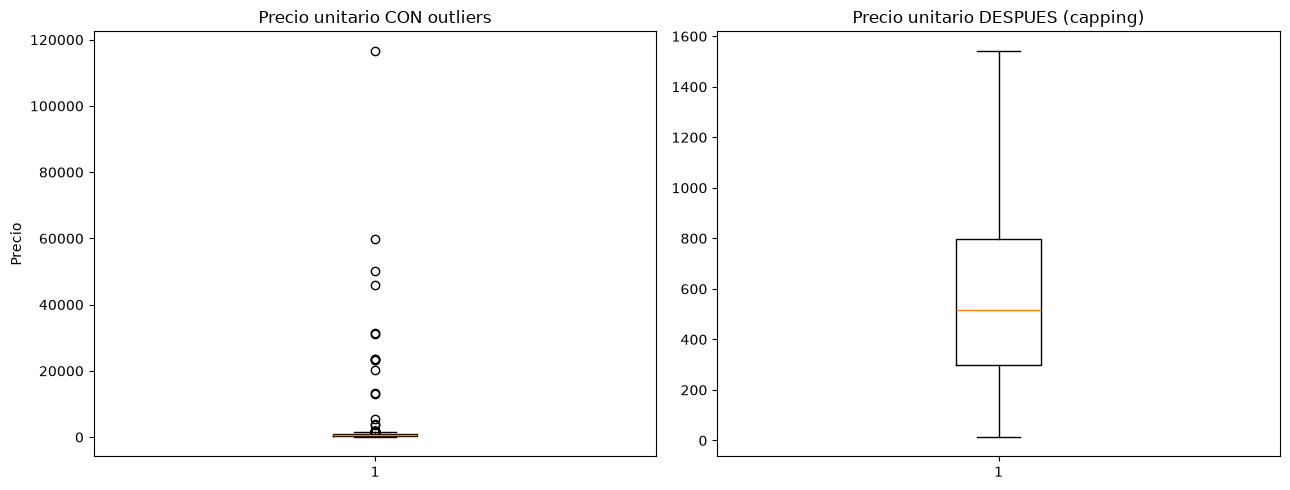

In [13]:
Q1 = df["precio_unitario"].quantile(0.25)
Q3 = df["precio_unitario"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df["precio_unitario"] < limite_inferior) | (df["precio_unitario"] > limite_superior)]
print(f"Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
print(f"Limites normales: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print(f"Numero de outliers detectados: {len(outliers)}")

# Visualizamos con un boxplot antes de tratar
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].boxplot(df["precio_unitario"])
axes[0].set_title("Precio unitario CON outliers"); axes[0].set_ylabel("Precio")

# Tratamiento: recortar (capping) al limite superior
df["precio_unitario"] = df["precio_unitario"].clip(upper=limite_superior)

axes[1].boxplot(df["precio_unitario"])
axes[1].set_title("Precio unitario DESPUES (capping)")
plt.tight_layout(); plt.show()

> **24.** ¿Cuántos outliers detectó el método IQR en `precio_unitario`? ¿Cuál es el límite superior calculado?

**Respuesta:** Detectó **32 outliers**. Con Q1 = 299.88, Q3 = 797.14 e IQR = 497.26, el límite superior es **\$1,543.04** (y el inferior −446.01, que en la práctica no aplica porque no hay precios negativos). Antes del tratamiento, el precio máximo llegaba a \$116,693.50 — 75 veces el límite.

> **25.** Explica el método IQR con tus palabras: ¿por qué se usa 1.5 × IQR como umbral?

**Respuesta:** El IQR es el ancho de la "caja": el rango donde vive el 50% central de los datos (entre Q1 y Q3). La idea es que un valor normal no debería alejarse demasiado de esa zona central; el umbral de **1.5 × IQR** más allá de los cuartiles es la convención propuesta por Tukey: lo bastante amplio para no marcar como raros valores normales, y lo bastante estrecho para atrapar los realmente extremos. No es una ley matemática sino un compromiso práctico que funciona bien en distribuciones típicas (con 3 × IQR se marcarían solo los extremos "severos").

> **26.** Compara los dos boxplots. ¿Cómo cambió la caja tras el "capping"? ¿Qué hace el método `.clip(upper=...)`?

**Respuesta:** En el boxplot original la caja se ve aplastada contra el fondo porque la escala tiene que llegar hasta ~116,000 para mostrar los outliers; tras el capping la escala llega a ~1,543 y la caja se aprecia con claridad, sin puntos extremos arriba. `.clip(upper=x)` **recorta**: todo valor mayor que `x` se reemplaza exactamente por `x`, y los valores menores quedan intactos. Es decir, los 32 precios extremos ahora valen \$1,543.04.

> **27.** El "capping" recorta los valores extremos al límite. Menciona otra estrategia posible para tratar outliers (por ejemplo, eliminarlos) y di cuándo sería preferible cada una.

**Respuesta:** Otras estrategias: **eliminar** las filas outlier, **transformar** la variable (p. ej. escala logarítmica, que comprime los extremos) o **dejarlos** y usar estadísticos robustos (mediana). Eliminar es preferible cuando el outlier es claramente un error de captura y la fila entera es sospechosa; el capping conviene cuando quieres conservar la fila (sus demás columnas son válidas) y solo neutralizar el valor extremo; la transformación logarítmica es ideal cuando los valores extremos son reales y la distribución es muy sesgada.

> **28.** ¿Todos los outliers son errores? Da un ejemplo de un outlier que sea un dato REAL y valioso (no un error) que NO deberíamos eliminar.

**Respuesta:** No, no todos son errores. Ejemplo: una **compra corporativa** genuina de \$100,000 en una tienda donde el ticket típico es de \$600, o el pico de ventas de un **Black Friday**. Son los registros más valiosos del negocio — identifican a los mejores clientes o los eventos más rentables — y eliminarlos "por ser raros" ocultaría exactamente lo que más interesa analizar. Por eso antes de tratar un outlier hay que preguntarse si es un error de datos o un fenómeno real.


## Paso 8 — Transformar y crear variables (feature engineering)

Con los datos limpios, creamos variables nuevas útiles para el análisis.


In [14]:
# Verificar la coherencia: precio_total deberia ser precio_unitario * cantidad
df["precio_total_calculado"] = (df["precio_unitario"] * df["cantidad"]).round(2)

# Crear una variable categorica: rango de precio
df["rango_precio"] = pd.cut(df["precio_unitario"],
                            bins=[0, 200, 500, 1000, np.inf],
                            labels=["Bajo", "Medio", "Alto", "Premium"])

print("Distribucion por rango de precio:")
print(df["rango_precio"].value_counts())

df[["precio_unitario", "cantidad", "precio_total_calculado", "rango_precio"]].head()

Distribucion por rango de precio:
rango_precio
Alto       237
Medio      195
Premium     94
Bajo        74
Name: count, dtype: int64


,precio_unitario,cantidad,precio_total_calculado,rango_precio
0,516.92,3,1550.76,Alto
1,448.66,1,448.66,Medio
2,516.92,1,516.92,Alto
3,15.11,1,15.11,Bajo
4,845.77,3,2537.31,Alto


> **29.** ¿Qué hace `pd.cut()`? ¿En qué se diferencia una variable continua (`precio_unitario`) de la variable categórica que creamos (`rango_precio`)?

**Respuesta:** `pd.cut()` **discretiza**: parte el rango de una variable numérica en intervalos (aquí 0-200, 200-500, 500-1000, 1000-∞) y asigna a cada fila la etiqueta del intervalo donde cae su valor (Bajo, Medio, Alto, Premium). La diferencia: `precio_unitario` es **continua** — puede tomar cualquier valor numérico y con ella se calculan medias, medianas, correlaciones —, mientras que `rango_precio` es **categórica ordinal** — solo toma 4 etiquetas con un orden, y sirve para agrupar, contar y segmentar. La distribución quedó: Alto 237, Medio 195, Premium 94, Bajo 74.

> **30.** ¿Por qué crear la columna `precio_total_calculado` es útil para verificar la calidad de los datos? (Pista: compárala con `precio_total`.)

**Respuesta:** Porque funciona como **verificación cruzada de coherencia**: si los datos fueran consistentes, `precio_total` debería ser igual a `precio_unitario × cantidad`. Al comparar, se descubre que difieren muchísimo: `precio_total` tiene media \$2,874 y máximo \$466,774, porque **arrastra los precios originales con outliers** (los totales se calcularon antes de nuestro capping), mientras que el calculado usa el precio ya recortado. Esa discrepancia es una alerta de calidad: nos dice que `precio_total` heredó la suciedad de los precios extremos y que, para el análisis, el valor recalculado es más confiable.


## Paso 9 — Dataset limpio: verificación final


In [15]:
print("=== RESUMEN DE LIMPIEZA ===")
print(f"Filas finales: {len(df)}")
print(f"Nulos totales restantes: {df.isnull().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")
print(f"Paises unicos: {df['pais'].nunique()}")
print(f"Categorias unicas: {df['categoria'].nunique()}")
print()
print("Estadisticas del dataset limpio:")
df[["precio_unitario", "cantidad", "precio_total", "calificacion", "edad_cliente"]].describe()

=== RESUMEN DE LIMPIEZA ===
Filas finales: 600
Nulos totales restantes: 90
Duplicados: 0
Paises unicos: 4
Categorias unicas: 4

Estadisticas del dataset limpio:


,precio_unitario,cantidad,precio_total,calificacion,edad_cliente
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,596.338967,1.596667,2874.393633,2.930000,34.063333
std,389.146344,0.960309,20895.842971,1.163625,10.045439
min,13.420000,1.000000,13.420000,1.000000,18.000000
25%,299.882500,1.000000,366.685000,2.000000,25.000000
50%,516.920000,1.000000,697.485000,3.000000,34.000000
75%,797.145000,2.000000,1278.882500,4.000000,34.000000
max,1543.038750,5.000000,466774.000000,5.000000,52.000000


> **31.** Compara el dataset final con el inicial: ¿cuántos nulos quedan? ¿Cuántos países y categorías únicas? Resume en 3 líneas qué logró la limpieza.

**Respuesta:** Quedan **90 nulos** (todos en `fecha`, por decisión deliberada del Reto 2), **4 países** y **4 categorías** únicas. Resumen: (1) pasamos de 630 filas con 30 duplicados, ~500 nulos repartidos y una columna de dinero ilegible como texto, a 600 filas únicas con tipos correctos; (2) unificamos 11 variantes de país y 9 de categoría en 4 y 4, y eliminamos edades imposibles (−5, 200), calificaciones inválidas (99) y 32 precios outlier; (3) el dataset quedó listo para producir estadísticas confiables, cosa imposible al inicio.

> **32.** Grafica la distribución de ventas por categoría con `df["categoria"].value_counts().plot(kind="bar")` en una celda. ¿Qué categoría vende más?

**Respuesta:** (Celda siguiente.) **Electrónica** es la que más vende, con **222 ventas**, seguida de Hogar (143), Ropa (119) y Juguetes (116). Ojo: parte de la ventaja de Electrónica es artificial — 48 de esas ventas eran nulos que imputamos con la moda, que justamente era Electrónica.


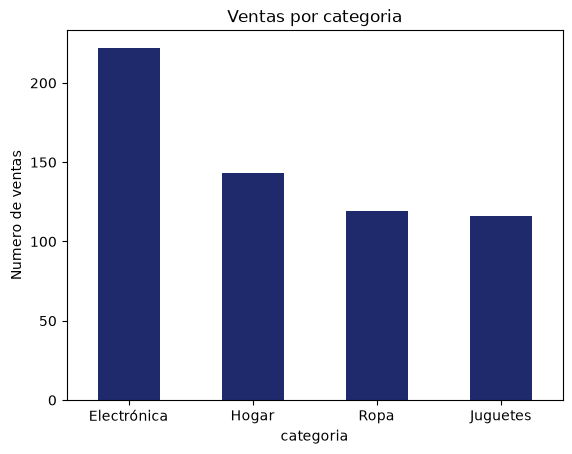

In [16]:
# P32: grafico de barras de ventas por categoria
df["categoria"].value_counts().plot(kind="bar", color="#1e2a6b")
plt.title("Ventas por categoria")
plt.ylabel("Numero de ventas")
plt.xticks(rotation=0)
plt.show()

---
# PARTE B — Tu turno (trabajo autónomo)

Ahora aplicarás lo aprendido a **otras fuentes de datos**. El profesor ya no te da el código completo: debes escribirlo tú.

## Paso 10 — Cargar datos desde JSON

Los datos de clientes están en formato **JSON**. Cárgalos y diagnostica su calidad.


In [17]:
# Cargar el JSON de clientes
with open("clientes.json", "r", encoding="utf-8") as f:
    datos_json = json.load(f)

clientes = pd.DataFrame(datos_json)
print("Clientes cargados:", clientes.shape)
clientes.head()

Clientes cargados: (150, 6)


,cliente_id,nombre,email,ciudad,compras_totales,gasto_total
0,2000,Carlos,NaN,Guadalajara,5,1734.47
1,2001,LUIS,sin_correo,Monterrey,0,706.45
2,2002,Carlos,a@mail.com,Guadalajara,2,1385.77
3,2003,,c@mail.com,Monterrey,14,348.98
4,2004,ana,sin_correo,Guadalajara,12,1459.75


> **33.** ¿Cuántos clientes y cuántas columnas hay? ¿Qué diferencia hay entre cargar un CSV y un JSON en cuanto a estructura?

**Respuesta:** Hay **150 clientes y 6 columnas** (`cliente_id`, `nombre`, `email`, `ciudad`, `compras_totales`, `gasto_total`). La diferencia: un **CSV** es plano y tabular — filas y columnas separadas por comas que pandas convierte directo en DataFrame —, mientras que un **JSON** es una estructura jerárquica de pares clave-valor (aquí, una lista de diccionarios, uno por cliente) que puede anidar objetos dentro de objetos. Hay que parsearlo primero (`json.load`) y luego convertirlo a tabla con `pd.DataFrame`; si tuviera campos anidados harían falta pasos extra como `pd.json_normalize`.

> **34.** Ejecuta `clientes.isnull().sum()`. ¿Qué columnas tienen nulos?

**Respuesta:** (Celda siguiente.) Tienen nulos **`email` (19)** y **`ciudad` (28)**. Ojo: `nombre` reporta 0 nulos pero es engañoso — tiene 20 cadenas vacías `""` que no cuentan como NaN hasta que las convirtamos (Reto 3).

> **35.** Observa la columna `nombre`: tiene valores como `" ana "`, `"LUIS"`, `""` (vacío). ¿Qué problemas de calidad identificas?

**Respuesta:** Tres problemas: (1) **espacios** sobrantes al inicio/final (`" ana "`), que hacen que " ana " y "Ana" cuenten como personas distintas; (2) **inconsistencia de mayúsculas** (`"LUIS"` vs `"Luis"`), mismo efecto; y (3) **vacíos disfrazados** (`""`), que son datos faltantes pero no aparecen en `isnull()` porque técnicamente son una cadena, no un NaN — el tipo de nulo "invisible" más traicionero.


In [18]:
# Exploracion de nulos y valores de clientes (P34-P35)
print("Nulos por columna:")
print(clientes.isnull().sum())
print()
print("Nombres unicos:", clientes["nombre"].unique())
print()
print("Emails unicos:", clientes["email"].unique())

Nulos por columna:
cliente_id          0
nombre              0
email              19
ciudad             28
compras_totales     0
gasto_total         0
dtype: int64

Nombres unicos: <StringArray>
['Carlos', 'LUIS', '', ' ana ', 'Ana', 'María', 'José', 'Sofía', 'Luis']
Length: 9, dtype: str

Emails unicos: <StringArray>
[nan, 'sin_correo', 'a@mail.com', 'c@mail.com', 'b@mail.com']
Length: 5, dtype: str


### Reto 3 — Limpia la columna `nombre`

Normaliza `nombre`: quita espacios, capitaliza (primera letra mayúscula) y reemplaza los vacíos `""` por NaN.


In [19]:
# RETO 3 resuelto: limpiar clientes["nombre"]
clientes["nombre"] = clientes["nombre"].str.strip().str.capitalize()
clientes["nombre"] = clientes["nombre"].replace("", np.nan)

print("Nombres unicos despues:", clientes["nombre"].dropna().unique())
print("Nulos en nombre (antes eran '' invisibles):", clientes["nombre"].isnull().sum())

Nombres unicos despues: <StringArray>
['Carlos', 'Luis', 'Ana', 'María', 'José', 'Sofía']
Length: 6, dtype: str
Nulos en nombre (antes eran '' invisibles): 20


> **36.** ¿Qué hace `.str.capitalize()`? Muestra los nombres únicos después de limpiar.

**Respuesta:** Pone la **primera letra en mayúscula y el resto en minúsculas**: `" ana "` → (tras strip) `"ana"` → `"Ana"`, y `"LUIS"` → `"Luis"`. Los nombres únicos después de limpiar quedaron: **Carlos, Luis, Ana, María, José y Sofía** — de 9 variantes bajamos a 6 nombres reales, más 20 registros que quedaron como NaN porque su nombre venía vacío (`""`).

> **37.** La columna `email` tiene valores como `"sin_correo"` y `None`. Escribe código para contar cuántos emails son inválidos (que no contengan "@"). ¿Cuántos hay?

**Respuesta:** (Celda siguiente.) Hay **56 emails inválidos**: 19 son `None` (nulos) y 37 son el texto `"sin_correo"`, que no es un nulo pero tampoco un correo — otro "faltante disfrazado". El truco es `fillna("")` antes de `str.contains("@")` para que los nulos también cuenten como inválidos en lugar de propagarse como NaN.


In [20]:
# P37: contar emails invalidos (sin "@")
invalidos = clientes["email"].fillna("").str.contains("@") == False
print("Emails invalidos:", invalidos.sum())
print("Desglose -> nulos:", clientes["email"].isnull().sum(),
      "| 'sin_correo':", (clientes["email"] == "sin_correo").sum())

Emails invalidos: 56
Desglose -> nulos: 19 | 'sin_correo': 37


### Reto 4 — Normaliza la columna `ciudad`

La columna `ciudad` tiene "CDMX", "cdmx", "Guadalajara", "GDL", etc. Unifícala con un diccionario de reemplazo, como hicimos con `pais`.


In [21]:
# RETO 4 resuelto: normalizar clientes["ciudad"]
clientes["ciudad"] = clientes["ciudad"].str.strip().str.upper()
mapa_ciudad = {
    "CDMX": "Ciudad de México",
    "GDL": "Guadalajara",
    "GUADALAJARA": "Guadalajara",
    "MONTERREY": "Monterrey",
}
clientes["ciudad"] = clientes["ciudad"].replace(mapa_ciudad)

print(clientes["ciudad"].value_counts())
print("\nNulos en ciudad:", clientes["ciudad"].isnull().sum())

ciudad
Guadalajara         52
Ciudad de México    47
Monterrey           23
Name: count, dtype: int64

Nulos en ciudad: 28


> **38.** ¿Cuántas ciudades únicas quedaron tras normalizar? ¿Qué variantes unificaste?

**Respuesta:** Quedaron **3 ciudades**: Guadalajara (52 clientes), Ciudad de México (47) y Monterrey (23), más 28 registros sin ciudad (nulos). Unifiqué **"cdmx" y "CDMX" → Ciudad de México** y **"GDL" y "Guadalajara" → Guadalajara**; con el `.str.upper()` previo, las variantes de mayúsculas/minúsculas quedaron resueltas antes de aplicar el diccionario.

> **39.** Calcula el `gasto_total` promedio por ciudad con `clientes.groupby("ciudad")["gasto_total"].mean()`. ¿Qué ciudad gasta más en promedio?

**Respuesta:** (Celda siguiente.) **Monterrey** gasta más en promedio (**\$1,004.47**), seguida de Guadalajara (\$963.60) y Ciudad de México (\$917.43). Nótese que sin la normalización del Reto 4 este cálculo habría sido imposible de interpretar: "GDL" y "Guadalajara" habrían aparecido como dos ciudades con promedios separados.


In [22]:
# P39: gasto promedio por ciudad
print(clientes.groupby("ciudad")["gasto_total"].mean().round(2).sort_values(ascending=False))

ciudad
Monterrey           1004.47
Guadalajara          963.60
Ciudad de México     917.43
Name: gasto_total, dtype: float64


## Paso 11 — Cargar datos desde SQL (SQLite)

Los productos están en una base de datos SQL. Se consultan con lenguaje SQL a través de pandas.


In [23]:
# Conectar a la base de datos y consultar
conn = sqlite3.connect("tienda.db")

# Consulta SQL: traer todos los productos
productos = pd.read_sql("SELECT * FROM productos", conn)
print("Productos cargados:", productos.shape)
print(productos.head())

conn.close()

Productos cargados: (80, 5)
   producto_id nombre_producto    categoria  stock  precio
0         3000      Producto 0         Ropa    198  512.87
1         3001      Producto 1     Juguetes    445  922.79
2         3002      Producto 2     Juguetes     35  280.37
3         3003      Producto 3     Juguetes    230  790.43
4         3004      Producto 4  Electrónica    285  343.45


> **40.** ¿Cuántos productos hay en la base de datos? ¿Qué columnas tiene la tabla `productos`?

**Respuesta:** Hay **80 productos** con **5 columnas**: `producto_id`, `nombre_producto`, `categoria`, `stock` y `precio`. A diferencia del CSV y el JSON, aquí los tipos ya vienen bien definidos desde la base (enteros y flotantes correctos), porque SQL obliga a declarar el tipo de cada columna al crear la tabla.

> **41.** ¿Qué ventaja tiene almacenar datos en una base SQL frente a un archivo CSV, para un negocio con millones de registros?

**Respuesta:** Varias decisivas: (1) se puede **consultar sin cargar todo** — un CSV hay que leerlo completo a memoria, mientras que SQL trae solo las filas y columnas que pides; (2) usa **índices** que hacen las búsquedas casi instantáneas aun con millones de filas; (3) garantiza **integridad**: tipos declarados, claves únicas, restricciones que impiden guardar basura como "edad = −5"; (4) permite **acceso concurrente** de muchos usuarios/aplicaciones a la vez con transacciones seguras, mientras que un CSV compartido se corrompe fácil; y (5) centraliza los datos en un solo lugar en vez de copias de archivos regadas.


### Reto 5 — Consulta SQL con filtro

Modifica la consulta para traer **solo los productos con stock menor a 50** (productos por reabastecer). Usa `WHERE stock < 50`.


In [24]:
# RETO 5 resuelto: consulta SQL con filtro de stock bajo
conn = sqlite3.connect("tienda.db")
bajo_stock = pd.read_sql("SELECT * FROM productos WHERE stock < 50", conn)
conn.close()

print("Productos con bajo stock:", len(bajo_stock))
print(bajo_stock)

Productos con bajo stock: 6
   producto_id nombre_producto    categoria  stock  precio
0         3002      Producto 2     Juguetes     35  280.37
1         3027     Producto 27     Juguetes     34  689.16
2         3045     Producto 45  Electrónica     12  654.53
3         3046     Producto 46     Juguetes     32  475.75
4         3064     Producto 64         Ropa     23   68.48
5         3067     Producto 67     Juguetes     33   99.01


> **42.** ¿Cuántos productos tienen stock menor a 50? ¿Por qué filtrar en la consulta SQL es más eficiente que cargar todo y filtrar en pandas, cuando la base es enorme?

**Respuesta:** **6 productos** están por reabastecer. Filtrar en SQL es más eficiente porque el filtro se ejecuta **dentro del motor de la base**, que usa sus índices y solo transfiere a Python las filas que cumplen la condición. Si la tabla tuviera 10 millones de productos, cargar todo a pandas significaría mover 10 millones de filas por red y memoria para luego tirar el 99.9%: con `WHERE` solo viajan las 6 filas que interesan. La regla general es: **empuja el filtrado lo más cerca posible de los datos**.

> **43.** Escribe una consulta SQL que traiga el **precio promedio por categoría** usando `SELECT categoria, AVG(precio) FROM productos GROUP BY categoria`. ¿Qué categoría es la más cara?

**Respuesta:** (Celda siguiente.) La más cara es **Juguetes** con precio promedio de **\$431.23**, seguida de Electrónica (\$386.01), Ropa (\$331.89) y Hogar (\$299.46). Este `GROUP BY` en SQL es el equivalente exacto del `groupby().mean()` de pandas, pero calculado dentro de la base.


In [25]:
# P43: precio promedio por categoria con SQL
conn = sqlite3.connect("tienda.db")
resultado = pd.read_sql(
    "SELECT categoria, AVG(precio) AS precio_prom FROM productos GROUP BY categoria",
    conn)
conn.close()

print(resultado.sort_values("precio_prom", ascending=False).round(2))

     categoria  precio_prom
2     Juguetes       431.22
0  Electrónica       386.01
3         Ropa       331.89
1        Hogar       299.46


## Paso 12 — Combinar fuentes (merge)

El verdadero poder aparece al **unir** datos de distintas fuentes. Unamos las ventas limpias con información adicional.


In [26]:
# Ejemplo: cuantas ventas hay por categoria (del CSV limpio)
ventas_por_cat = df.groupby("categoria").agg(
    num_ventas=("id_venta", "count"),
    precio_promedio=("precio_unitario", "mean")
).round(2)
print("Resumen de ventas por categoria (dataset limpio):")
print(ventas_por_cat)

Resumen de ventas por categoria (dataset limpio):
             num_ventas  precio_promedio
categoria                               
Electrónica         222           593.08
Hogar               143           618.83
Juguetes            116           594.73
Ropa                119           576.95


> **44.** ¿Qué hace el método `groupby().agg()`? Explica qué calcula cada línea del `agg`.

**Respuesta:** `groupby("categoria")` parte el DataFrame en un grupo por categoría, y `.agg()` calcula estadísticas **por grupo**, cada una con nombre propio: `num_ventas=("id_venta", "count")` cuenta cuántas ventas (filas con id) tiene cada categoría, y `precio_promedio=("precio_unitario", "mean")` calcula el precio unitario promedio de cada categoría. El resultado es una tabla resumen: Electrónica 222 ventas con precio medio \$593.08, Hogar 143 y \$618.83, Juguetes 116 y \$594.73, Ropa 119 y \$576.95.

> **45.** Investiga brevemente: ¿qué es un `merge` (o `join`) en pandas y para qué serviría unir la tabla de ventas con la de clientes? Da un ejemplo de qué pregunta podrías responder al unirlas.

**Respuesta:** Un `merge` combina dos DataFrames emparejando filas por una columna clave común (como el `JOIN` de SQL): `pd.merge(ventas, clientes, on="cliente_id")` pegaría a cada venta los datos del cliente que la hizo. Sirve para cruzar información que vive en fuentes distintas. Ejemplo de pregunta que solo se puede responder uniendo: **"¿qué ciudad genera más ingresos por ventas?"** — la ciudad está en la tabla de clientes (JSON) y el monto en la de ventas (CSV) — o "¿los clientes que más compras acumulan dejan mejores calificaciones?".


## Paso 13 — Análisis final e interpretación


=== ANALISIS DEL DATASET LIMPIO ===

Venta promedio: $2874.39
Calificacion promedio: 2.93
Edad promedio del cliente: 34.1 años

Metodo de pago mas usado: Efectivo
Pais con mas ventas: México


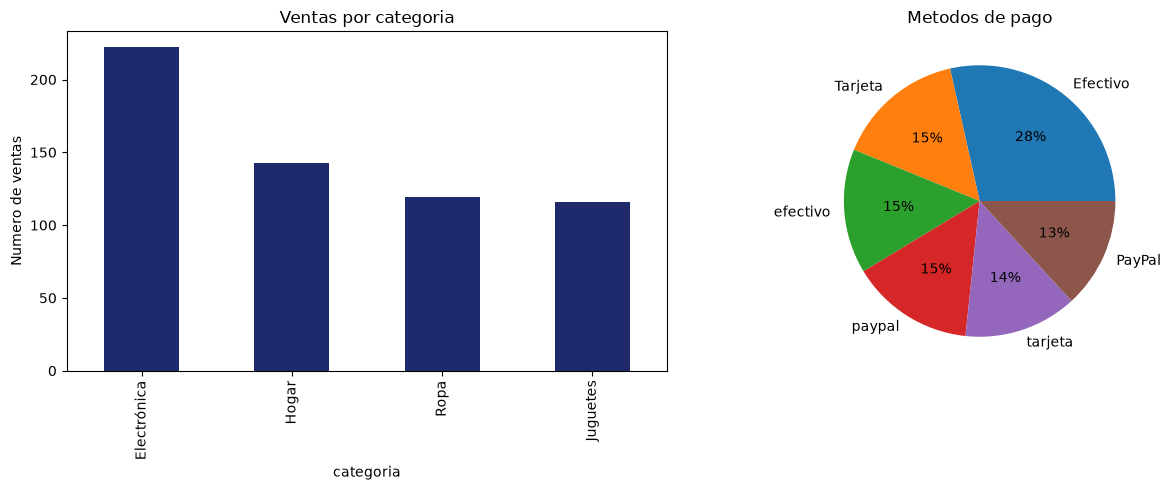

In [27]:
# Un analisis integral sobre los datos limpios
print("=== ANALISIS DEL DATASET LIMPIO ===")
print(f"\nVenta promedio: ${df['precio_total'].mean():.2f}")
print(f"Calificacion promedio: {df['calificacion'].mean():.2f}")
print(f"Edad promedio del cliente: {df['edad_cliente'].mean():.1f} años")
print(f"\nMetodo de pago mas usado: {df['metodo_pago'].mode()[0]}")
print(f"Pais con mas ventas: {df['pais'].mode()[0]}")

# Grafico resumen
fig, axes = plt.subplots(1, 2, figsize=(13,5))
df["categoria"].value_counts().plot(kind="bar", ax=axes[0], color="#1e2a6b")
axes[0].set_title("Ventas por categoria"); axes[0].set_ylabel("Numero de ventas")
df["metodo_pago"].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.0f%%")
axes[1].set_title("Metodos de pago"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

> **46.** Según el análisis, ¿cuál es la venta promedio, la calificación promedio y el método de pago más usado?

**Respuesta:** Venta promedio: **\$2,874.39** (ojo: sigue inflada porque `precio_total` conserva los outliers originales — la media del recalculado sería mucho menor). Calificación promedio: **2.93** sobre 5 (clientes más bien insatisfechos). Método de pago más usado: **Efectivo** (en parte porque los 79 nulos se imputaron con esa moda). El cliente promedio tiene 34.1 años y el país líder es México.

> **47.** ¿Habría sido posible hacer este análisis correctamente SIN limpiar los datos primero? Explica qué habría salido mal en cada estadística (por ejemplo, el promedio de precio con los outliers).

**Respuesta:** No. Cada estadística habría fallado a su manera: la **venta promedio ni siquiera se habría podido calcular** (`precio_total` era texto con `"$"` — error inmediato); el **precio unitario promedio** habría salido disparado por los outliers de hasta \$116,693; la **calificación promedio** habría rebasado la escala por los 99 (habría dado un valor absurdo mayor a 5 en una escala 1-5); la **edad promedio** estaría distorsionada por los −5 y 200; los **conteos por país y categoría** estarían fragmentados en 11 y 9 variantes falsas; y los 30 **duplicados** inflarían todos los totales. Cada problema arruina una estadística distinta — por eso la auditoría inicial revisa todos.

> **48.** De todas las técnicas de limpieza que aplicaste (duplicados, tipos, nulos, texto, outliers, valores imposibles), ¿cuál te pareció más importante para este dataset y por qué?

**Respuesta:** La **corrección de tipos** (`precio_total` de texto a número), porque es la única que **bloqueaba por completo** el análisis: sin ella no hay promedio, suma ni comparación posible — el resto de problemas distorsionan resultados, pero este impide siquiera calcularlos. En segundo lugar pondría los **valores imposibles**, porque son los más traicioneros: un 99 en calificación no lanza ningún error, se cuela silenciosamente en el promedio y produce conclusiones falsas que nadie nota.

> **49.** Un compañero dice: "Limpiar datos es aburrido y no es parte 'real' de la ciencia de datos". Argumenta por qué está equivocado, con ejemplos de esta actividad.

**Respuesta:** Está equivocado porque **la calidad del análisis se decide en la limpieza**, no en el modelo. En esta misma actividad: si no quitamos los 99, reportaríamos clientes "felices" con calificación >5 cuando la real es 2.93; si no unificamos "mexico/México/MX", el ranking de países sería falso; si no tratamos los outliers, el precio promedio saldría inflado varias veces. Además, limpiar **es** tomar decisiones analíticas: elegir mediana vs media, imputar vs eliminar, capping vs borrar outliers son juicios estadísticos y de negocio, no tareas mecánicas. Un científico de datos que no sabe limpiar produce análisis bonitos sobre datos falsos.

> **50 (reflexión).** En tu carrera de Ingeniería en Computación, ¿en qué situación real tendrías que limpiar datos sucios? (Por ejemplo: logs de un servidor, datos de sensores IoT, registros de usuarios). Describe qué problemas de calidad esperarías encontrar.

**Respuesta:** Un caso muy directo: **logs de un servidor web** para analizar errores y rendimiento. Esperaría encontrar: timestamps en formatos mezclados según el servicio que escribió el log (igual que nuestra columna `fecha`); líneas duplicadas por reintentos automáticos de las peticiones (como nuestros 30 duplicados); campos vacíos cuando un request se corta a la mitad (nulos); códigos de estado o IPs corruptos por líneas mal escritas (valores imposibles); y tiempos de respuesta absurdos de 10 minutos causados por timeouts, que son los outliers a decidir si recortar o investigar. También en **registros de usuarios** de cualquier aplicación: emails inválidos tipo "sin_correo", nombres con mayúsculas y espacios inconsistentes, y ciudades escritas de cinco formas — exactamente lo que limpiamos en el JSON de clientes.


---
## Cierre y entrega

Aprendiste a cargar datos desde **tres fuentes** (CSV, JSON, SQL) y aplicaste el flujo completo de **data wrangling**: diagnóstico, duplicados, tipos, texto inconsistente, nulos, valores imposibles, outliers y creación de variables. Sobre todo, comprobaste que **sin datos limpios no hay análisis confiable**.

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error** (Entorno de ejecución → Ejecutar todo).
2. Confirma que respondiste las **50 preguntas** y los **5 retos de código**.
3. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Todas las celdas se ejecutan correctamente | 10 |
| Retos de código resueltos (5) | 25 |
| Respuestas a las 50 preguntas | 45 |
| Calidad del análisis e interpretación | 15 |
| Orden y documentación | 5 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Datasets: ventas_sucias.csv, clientes.json, tienda.db*
